In [1]:
# CELL 1 — Install/imports
# Run this first in Kaggle

import os
import math
import time
import random
import requests
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Torch version: 2.9.0+cpu
CUDA available: False
Using device: cpu


In [2]:
# CELL 2 — Config

SEED = 42

# data
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
LOCAL_TXT = "/kaggle/working/input.txt"

# model
BATCH_SIZE = 64
BLOCK_SIZE = 128
MAX_ITERS = 5000
EVAL_INTERVAL = 500
LEARNING_RATE = 3e-4
EVAL_ITERS = 200
N_EMBD = 192
N_HEAD = 6
N_LAYER = 6
DROPOUT = 0.2

# v0.2.0 training improvements
GRAD_CLIP = 1.0
WARMUP_ITERS = 100
MIN_LR_RATIO = 0.05   # final lr = 5% of base lr

# generation improvements
GENERATE_TOKENS = 500
TEMPERATURE = 0.9
TOP_K = 40

# checkpoint paths
BEST_MODEL_PATH = "/kaggle/working/logos_best_v0_2_0_alpha.pth"

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("Config loaded.")

Config loaded.


In [3]:
# CELL 3 — Load Tiny Shakespeare text
# This tries:
# 1) existing /kaggle/working/input.txt
# 2) download from URL
# You can also replace LOCAL_TXT with your own uploaded text file path.

if not os.path.exists(LOCAL_TXT):
    r = requests.get(DATA_URL, timeout=30)
    r.raise_for_status()
    with open(LOCAL_TXT, "w", encoding="utf-8") as f:
        f.write(r.text)

with open(LOCAL_TXT, "r", encoding="utf-8") as f:
    text = f.read()

print("Dataset length:", len(text))
print(text[:500])

Dataset length: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [4]:
# CELL 4 — Character-level tokenizer

chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

def encode(s):
    return [stoi[c] for c in s]

def decode(ids):
    return "".join([itos[i] for i in ids])

data = torch.tensor(encode(text), dtype=torch.long)

print("Vocab size:", vocab_size)
print("Sample chars:", chars[:20])
print("Encoded sample:", data[:20].tolist())
print("Decoded sample:", decode(data[:20].tolist()))

Vocab size: 65
Sample chars: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G']
Encoded sample: [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56]
Decoded sample: First Citizen:
Befor


In [5]:
# CELL 5 — Train/validation split

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print("Train tokens:", len(train_data))
print("Val tokens:", len(val_data))

Train tokens: 1003854
Val tokens: 111540


In [6]:
# CELL 6 — Batch loader

def get_batch(split):
    source = train_data if split == "train" else val_data
    ix = torch.randint(len(source) - BLOCK_SIZE - 1, (BATCH_SIZE,))
    x = torch.stack([source[i:i + BLOCK_SIZE] for i in ix])
    y = torch.stack([source[i + 1:i + BLOCK_SIZE + 1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch("train")
print("x shape:", xb.shape)
print("y shape:", yb.shape)

x shape: torch.Size([64, 128])
y shape: torch.Size([64, 128])


In [7]:
# CELL 7 — Loss estimation

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ["train", "val"]:
        losses = torch.zeros(EVAL_ITERS)
        for k in range(EVAL_ITERS):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

In [8]:
# CELL 8 — Attention head

class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(N_EMBD, head_size, bias=False)
        self.query = nn.Linear(N_EMBD, head_size, bias=False)
        self.value = nn.Linear(N_EMBD, head_size, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(BLOCK_SIZE, BLOCK_SIZE)))
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)      # (B,T,hs)
        q = self.query(x)    # (B,T,hs)

        wei = q @ k.transpose(-2, -1) * (k.size(-1) ** -0.5)   # (B,T,T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        v = self.value(x)    # (B,T,hs)
        out = wei @ v        # (B,T,hs)
        return out

In [9]:
# CELL 9 — Multi-head attention

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(N_EMBD, N_EMBD)
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

In [10]:
# CELL 10 — Feed-forward network

class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(DROPOUT),
        )

    def forward(self, x):
        return self.net(x)

In [11]:
# CELL 11 — Transformer block

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

In [12]:
# CELL 12 — Full mini Transformer language model

class MiniTransformerLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, N_EMBD)
        self.position_embedding_table = nn.Embedding(BLOCK_SIZE, N_EMBD)
        self.blocks = nn.Sequential(*[Block(N_EMBD, N_HEAD) for _ in range(N_LAYER)])
        self.ln_f = nn.LayerNorm(N_EMBD)
        self.lm_head = nn.Linear(N_EMBD, vocab_size)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits_flat = logits.view(B * T, C)
            targets_flat = targets.view(B * T)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        if temperature <= 0:
            raise ValueError("temperature must be > 0")

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -BLOCK_SIZE:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature

            if top_k is not None:
                k = min(top_k, logits.size(-1))
                top_vals, _ = torch.topk(logits, k)
                cutoff = top_vals[:, -1].unsqueeze(-1)
                logits = torch.where(
                    logits < cutoff,
                    torch.full_like(logits, float("-inf")),
                    logits
                )

            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)

        return idx

model = MiniTransformerLM().to(device)
param_count = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {param_count:,}")

MiniTransformerLM(
  (token_embedding_table): Embedding(65, 192)
  (position_embedding_table): Embedding(128, 192)
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (heads): ModuleList(
          (0-5): 6 x Head(
            (key): Linear(in_features=192, out_features=32, bias=False)
            (query): Linear(in_features=192, out_features=32, bias=False)
            (value): Linear(in_features=192, out_features=32, bias=False)
            (dropout): Dropout(p=0.2, inplace=False)
          )
        )
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (ffwd): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=192, out_features=768, bias=True)
          (1): ReLU()
          (2): Linear(in_features=768, out_features=192, bias=True)
          (3): Dropout(p=0.2, inplace=False)
        )
      )
      (ln1): LayerNorm((192,), eps=1e-05, elementwise_affine=

In [13]:
# CELL 13 — Optimizer + warmup-cosine scheduler

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

def lr_lambda(step):
    if step < WARMUP_ITERS:
        return float(step + 1) / float(max(1, WARMUP_ITERS))

    progress = (step - WARMUP_ITERS) / float(max(1, MAX_ITERS - WARMUP_ITERS))
    progress = min(max(progress, 0.0), 1.0)

    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return MIN_LR_RATIO + (1.0 - MIN_LR_RATIO) * cosine

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

print("Optimizer ready.")
print(f"Initial LR: {optimizer.param_groups[0]['lr']:.6f}")

Optimizer ready.
Initial LR: 0.000003


In [14]:
# CELL 14 — Training loop with gradient clipping + best checkpoint tracking

train_losses = []
val_losses = []
steps = []
lr_history = []

best_val_loss = float("inf")
best_iter = -1
best_state_dict = None

start_time = time.time()

model.train()
for iter_idx in range(MAX_ITERS):
    if iter_idx % EVAL_INTERVAL == 0 or iter_idx == MAX_ITERS - 1:
        losses = estimate_loss()
        train_losses.append(losses["train"])
        val_losses.append(losses["val"])
        steps.append(iter_idx)
        lr_history.append(optimizer.param_groups[0]["lr"])

        print(
            f"step {iter_idx:5d} | "
            f"lr {optimizer.param_groups[0]['lr']:.6f} | "
            f"train loss {losses['train']:.4f} | "
            f"val loss {losses['val']:.4f}"
        )

        if losses["val"] < best_val_loss:
            best_val_loss = losses["val"]
            best_iter = iter_idx
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    xb, yb = get_batch("train")
    logits, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

    optimizer.step()
    scheduler.step()

end_time = time.time()
print(f"\nTraining completed in {(end_time - start_time) / 60:.2f} minutes.")

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    model.to(device)
    print(f"Restored best checkpoint from step {best_iter} with val loss {best_val_loss:.4f}")
else:
    print("Warning: no best checkpoint was captured.")

step     0 | lr 0.000003 | train loss 4.1834 | val loss 4.1805
step   500 | lr 0.000295 | train loss 1.9633 | val loss 2.0389
step  1000 | lr 0.000277 | train loss 1.5949 | val loss 1.7648
step  1500 | lr 0.000246 | train loss 1.4667 | val loss 1.6641
step  2000 | lr 0.000207 | train loss 1.3931 | val loss 1.5992
step  2500 | lr 0.000162 | train loss 1.3464 | val loss 1.5678
step  3000 | lr 0.000117 | train loss 1.3142 | val loss 1.5339
step  3500 | lr 0.000076 | train loss 1.2872 | val loss 1.5244
step  4000 | lr 0.000043 | train loss 1.2775 | val loss 1.5109
step  4500 | lr 0.000022 | train loss 1.2680 | val loss 1.5066
step  4999 | lr 0.000015 | train loss 1.2586 | val loss 1.5042

Training completed in 256.37 minutes.
Restored best checkpoint from step 4999 with val loss 1.5042


In [15]:
# CELL 15 — Save best model checkpoint

torch.save({
    "model_state_dict": model.state_dict(),
    "config": {
        "SEED": SEED,
        "BATCH_SIZE": BATCH_SIZE,
        "BLOCK_SIZE": BLOCK_SIZE,
        "MAX_ITERS": MAX_ITERS,
        "LEARNING_RATE": LEARNING_RATE,
        "N_EMBD": N_EMBD,
        "N_HEAD": N_HEAD,
        "N_LAYER": N_LAYER,
        "DROPOUT": DROPOUT,
        "GRAD_CLIP": GRAD_CLIP,
        "WARMUP_ITERS": WARMUP_ITERS,
        "MIN_LR_RATIO": MIN_LR_RATIO,
        "TEMPERATURE": TEMPERATURE,
        "TOP_K": TOP_K,
        "vocab_size": vocab_size,
        "chars": chars,
    },
    "best_val_loss": best_val_loss,
    "best_iter": best_iter,
    "train_losses": train_losses,
    "val_losses": val_losses,
    "steps": steps,
    "lr_history": lr_history,
}, BEST_MODEL_PATH)

print("Best checkpoint saved to:", BEST_MODEL_PATH)

Best checkpoint saved to: /kaggle/working/logos_best_v0_2_0_alpha.pth


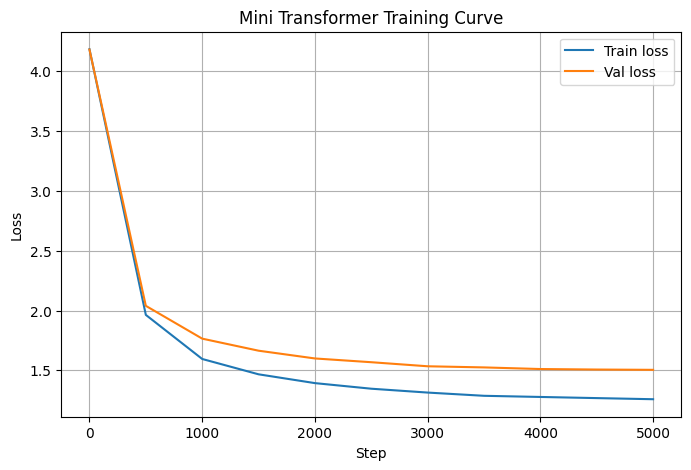

In [16]:
# CELL 16 — Plot training/validation loss

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(steps, train_losses, label="Train loss")
plt.plot(steps, val_losses, label="Val loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Mini Transformer Training Curve")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# CELL 17 — Text generation with temperature + top-k sampling

model.eval()
with torch.no_grad():
    context = torch.zeros((1, 1), dtype=torch.long, device=device)
    generated = model.generate(
        context,
        max_new_tokens=GENERATE_TOKENS,
        temperature=TEMPERATURE,
        top_k=TOP_K
    )[0].tolist()

print(f"Generation settings -> temperature={TEMPERATURE}, top_k={TOP_K}\n")
print(decode(generated))

Generation settings -> temperature=0.9, top_k=40


First, sir, and time, he shall repent your liht;
And strange of such our misfortune this head possible,
And us he this brother, which 'Tis it was be if
With hang an old to the countime, and a came
Of warrow show in a lady pies her will-married,
that I make what you should not, I'll do, in my deed,
As you'll die; you proceed too, Capitol,
Will have hear such a shamber and fear come of him,
And that's you swear her from well. This did condict
My husband shall I ssure a balm.

GLOUCESTER:
Did mind 


In [18]:
# CELL 18 — Perplexity on restored best checkpoint

losses = estimate_loss()
train_ppl = math.exp(losses["train"])
val_ppl = math.exp(losses["val"])

print(f"Best checkpoint step: {best_iter}")
print(f"Best validation loss recorded during training: {best_val_loss:.4f}")
print(f"Train loss: {losses['train']:.4f}")
print(f"Val loss:   {losses['val']:.4f}")
print(f"Train perplexity: {train_ppl:.2f}")
print(f"Val perplexity:   {val_ppl:.2f}")

Best checkpoint step: 4999
Best validation loss recorded during training: 1.5042
Train loss: 1.2607
Val loss:   1.5055
Train perplexity: 3.53
Val perplexity:   4.51


In [19]:
# CELL 19 — Simple generation quality check

model.eval()
with torch.no_grad():
    context = torch.zeros((1, 1), dtype=torch.long, device=device)
    generated_ids = model.generate(
        context,
        max_new_tokens=GENERATE_TOKENS,
        temperature=TEMPERATURE,
        top_k=TOP_K
    )[0].tolist()

generated_text = decode(generated_ids)

print("=== Generation Quality Check ===")
print(f"Generated length: {len(generated_text)} characters")
print(f"Unique chars used: {len(set(generated_text))}")
print(f"Generation settings: temperature={TEMPERATURE}, top_k={TOP_K}")

current_losses = estimate_loss()
current_val_ppl = math.exp(current_losses["val"])
print(f"Model val perplexity: {current_val_ppl:.2f}  (lower = more predictable/coherent output)")

print("\n=== Sample Output ===\n")
print(generated_text)

=== Generation Quality Check ===
Generated length: 501 characters
Unique chars used: 45
Generation settings: temperature=0.9, top_k=40
Model val perplexity: 4.51  (lower = more predictable/coherent output)

=== Sample Output ===


Shall be our foes own to about out so.

COMINIUS:
Come, it is grace.

POMPEY:
Ay, sir, sir, my lord.

CORIOLANUS:
Come, he hath been out of the countimely. The two loss
My rage confession of thy divine,
And how on was the part winter heart of heavy come?

GLOUCESTER:
Not please a day: and she will, my lord: good lord.
O God's lord, and with my life and hath said 'banish'd,
A man thou art off his valour.'
Forthward is my time, what do you thou leave, sir,
To leave the king good passion with him.

